# FaceDetector Processing

---

Tahapan ini mencakup pengambilan, pemrosesan dan evaluasi untuk skenario tugas dan istirahat
- Mengambil data dari file npy
- Melakukan pre-processing pada sinyal rPPG dan PPG
- Melakukan extraksi HR dan HRV (SDNN dan RMSSD)
- Evaluasi MAE, RMSE dan PC

In [222]:
## Importing Dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk
import scipy
import os
from prettytable import PrettyTable
from dataclasses import dataclass
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
import numpy as np


In [223]:
@dataclass
class SignalData:
    subject: str
    task: str
    method: str  
    raw: np.ndarray
    fs: int
    preprocessed: np.ndarray = None


## Preprocessing & Signal Extraction

### Define the processing method (Preprocess, Ekstraksi HR / HRV Metrik Pipeline)
---

In [224]:
def preprocess_rppg(rppg_signal, ppg_signal, fs_rppg=35, fs_ppg=64,):
    # Time bases
    t_rppg = np.arange(len(rppg_signal)) / fs_rppg
    t_ppg  = np.arange(len(ppg_signal)) / fs_ppg

    # Interpolation to PPG Samples Length
    cs = scipy.interpolate.CubicSpline(t_rppg, rppg_signal)
    rppg_up = cs(t_ppg)

    # Bandpass filter rPPG
    b, a = scipy.signal.butter(3, [0.7, 2.5], btype='band', fs=fs_ppg)
    rppg_filtered = scipy.signal.filtfilt(b, a, rppg_up)

    # Normalize signals
    rppg_filtered = (rppg_filtered - np.mean(rppg_filtered)) / np.std(rppg_filtered)

    return rppg_filtered


In [225]:
def preprocess_ppg(ppg_signal, fs_ppg=64):

    # Bandpass filter the PPG signal
    b, a = scipy.signal.butter(3, [0.7, 2.5], btype='band', fs=fs_ppg)
    ppg_filtered = scipy.signal.filtfilt(b, a, ppg_signal)

    # Normalize the signal
    ppg_filtered = (ppg_filtered - np.mean(ppg_filtered)) / np.std(ppg_filtered)

    return ppg_filtered


Main Methods

---

Opening the npy files for FaceDetector

In [226]:
root_path = "dataset_numpy"
subjects = ["s41", "s42", "s43", "s44","s45","s46","s47","s48","s49","s50","s51","s52", "s53","s54","s55","s56"]
tasks = ["T1", "T3"] # Rest, Task

sample_rate_gt = 64  # Hz
sample_rate_video = 35 # Hz

all_signals = []

for subject in subjects:
    for task in tasks:
        # --- Ground truth PPG ---
        gt_file = os.path.join(root_path, subject, f"bvp_{subject}_{task}.csv")
        gt_data = pd.read_csv(gt_file, header=None).values.flatten()
        gt_signal = preprocess_ppg(gt_data, fs_ppg=sample_rate_gt)

        all_signals.append(
            SignalData(
                subject=subject,
                task=task,
                method="PPG",
                raw=gt_data,
                fs=sample_rate_gt,
                preprocessed=gt_signal
            )
        )

        # --- rPPG methods ---
        for method in ["POS", "LGI", "OMIT", "GREEN", "CHROM"]:
            file_path = os.path.join(root_path, subject, f"{subject}_{task}_{method}_rppg.npy")
            rppg_raw = np.load(file_path)

            rppg_preproc = preprocess_rppg(rppg_raw, gt_data,
                                           fs_rppg=sample_rate_video,
                                           fs_ppg=sample_rate_gt)

            all_signals.append(
                SignalData(
                    subject=subject,
                    task=task,
                    method=method,
                    raw=rppg_raw,
                    fs=64,
                    preprocessed=rppg_preproc
                )
            )

# Sanity check the pipeline for the result
# Expected all methods should have length of 11520 (64 Hz * 180 sec = 11520 samples long)
summary = pd.DataFrame([{
    "Subject": sig.subject,
    "Task": sig.task,
    "Method": sig.method,
    "RawLen": len(sig.raw),
    "PreprocLen": len(sig.preprocessed)
} for sig in all_signals])

print(summary.head(20))


   Subject Task Method  RawLen  PreprocLen
0      s41   T1    PPG   11520       11520
1      s41   T1    POS    6325       11520
2      s41   T1    LGI    6325       11520
3      s41   T1   OMIT    6325       11520
4      s41   T1  GREEN    6325       11520
5      s41   T1  CHROM    6300       11520
6      s41   T3    PPG   11520       11520
7      s41   T3    POS    6325       11520
8      s41   T3    LGI    6325       11520
9      s41   T3   OMIT    6325       11520
10     s41   T3  GREEN    6325       11520
11     s41   T3  CHROM    6300       11520
12     s42   T1    PPG   11520       11520
13     s42   T1    POS    6325       11520
14     s42   T1    LGI    6325       11520
15     s42   T1   OMIT    6325       11520
16     s42   T1  GREEN    6325       11520
17     s42   T1  CHROM    6300       11520
18     s42   T3    PPG   11520       11520
19     s42   T3    POS    6325       11520


In [227]:
for signal in all_signals:
    # 1) durations
    print(f"durations (s): signal - {signal.method}:", len(signal.preprocessed)/signal.fs)

    # 2) endpoints (time axes)
    print("signal last:", (len(signal.preprocessed)-1)/signal.fs)

    # 3) expected upsampled length
    expected_len = int(round(len(signal.preprocessed) * signal.fs / signal.fs))
    print("expected length after resample:", expected_len)

    # 4) a quick peak sanity (after your current preprocess)
    peaks_ppg, _ = scipy.signal.find_peaks(signal.preprocessed, prominence=0.5, distance=int(0.4*signal.fs))
    print(f"len(peaks): {signal.method}", len(peaks_ppg))
    print("first 10 PPG peaks (samples):", peaks_ppg[:10])

    print (" ================================ ")


durations (s): signal - PPG: 180.0
signal last: 179.984375
expected length after resample: 11520
len(peaks): PPG 290
first 10 PPG peaks (samples): [ 20  60  98 136 175 214 254 296 343 387]
durations (s): signal - POS: 180.0
signal last: 179.984375
expected length after resample: 11520
len(peaks): POS 289
first 10 PPG peaks (samples): [ 53  91 130 175 218 258 307 337 376 411]
durations (s): signal - LGI: 180.0
signal last: 179.984375
expected length after resample: 11520
len(peaks): LGI 289
first 10 PPG peaks (samples): [ 10  53  91 130 174 218 258 307 337 380]
durations (s): signal - OMIT: 180.0
signal last: 179.984375
expected length after resample: 11520
len(peaks): OMIT 289
first 10 PPG peaks (samples): [ 10  53  91 130 174 218 258 307 337 380]
durations (s): signal - GREEN: 180.0
signal last: 179.984375
expected length after resample: 11520
len(peaks): GREEN 266
first 10 PPG peaks (samples): [ 38  94 129 165 191 225 264 312 389 447]
durations (s): signal - CHROM: 180.0
signal last:

len(peaks): OMIT 222
first 10 PPG peaks (samples): [ 45  92 138 188 239 289 334 379 428 478]
durations (s): signal - GREEN: 180.0
signal last: 179.984375
expected length after resample: 11520
len(peaks): GREEN 222
first 10 PPG peaks (samples): [ 48  91 138 189 242 290 333 378 426 479]
durations (s): signal - CHROM: 180.0
signal last: 179.984375
expected length after resample: 11520
len(peaks): CHROM 223
first 10 PPG peaks (samples): [ 69 112 161 213 264 311 355 398 454 503]
durations (s): signal - PPG: 180.0
signal last: 179.984375
expected length after resample: 11520
len(peaks): PPG 267
first 10 PPG peaks (samples): [ 12  67 105 146 204 249 292 326 367 423]
durations (s): signal - POS: 180.0
signal last: 179.984375
expected length after resample: 11520
len(peaks): POS 256
first 10 PPG peaks (samples): [ 63 110 158 206 250 294 337 392 441 483]
durations (s): signal - LGI: 180.0
signal last: 179.984375
expected length after resample: 11520
len(peaks): LGI 254
first 10 PPG peaks (sample

Notes:

---

The signal been in the same length and preprocessed

and it's fine to move on to the HR / HRV Extraction

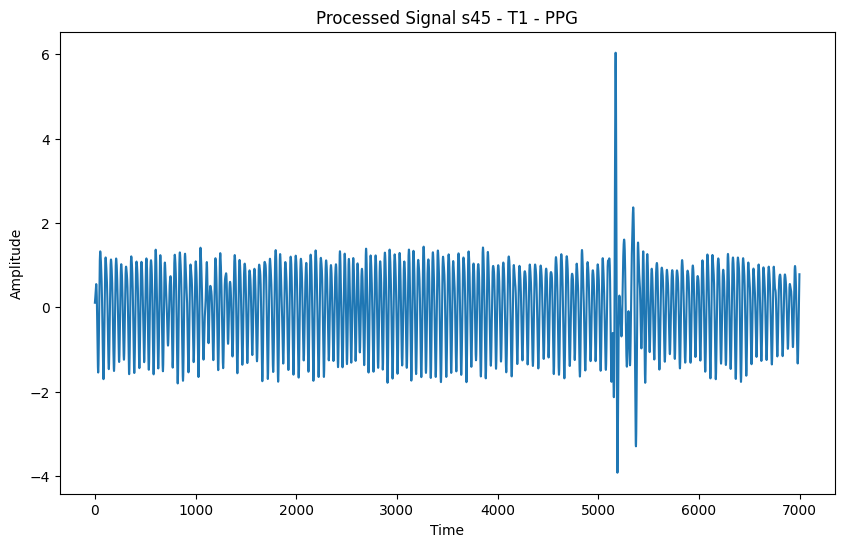

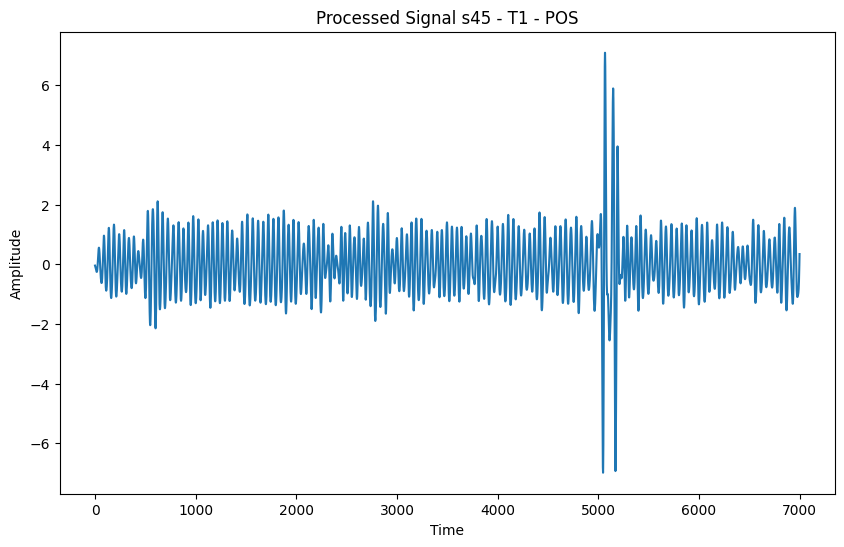

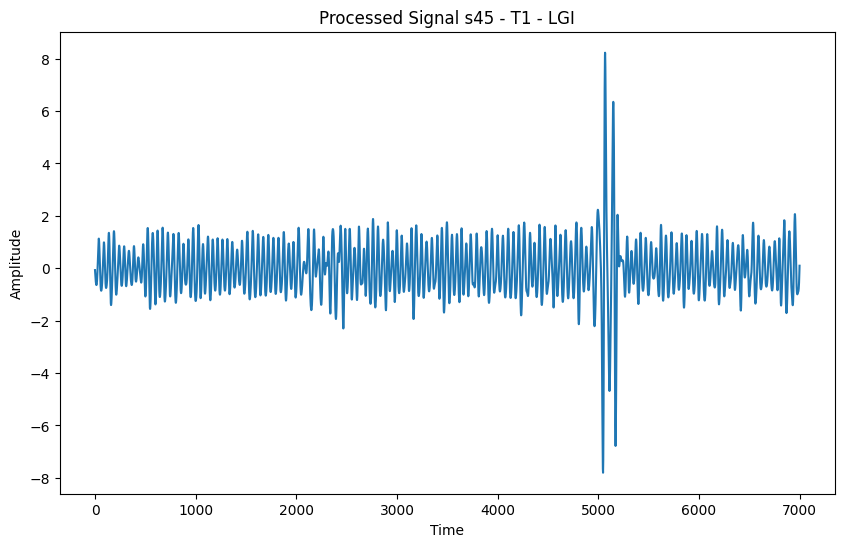

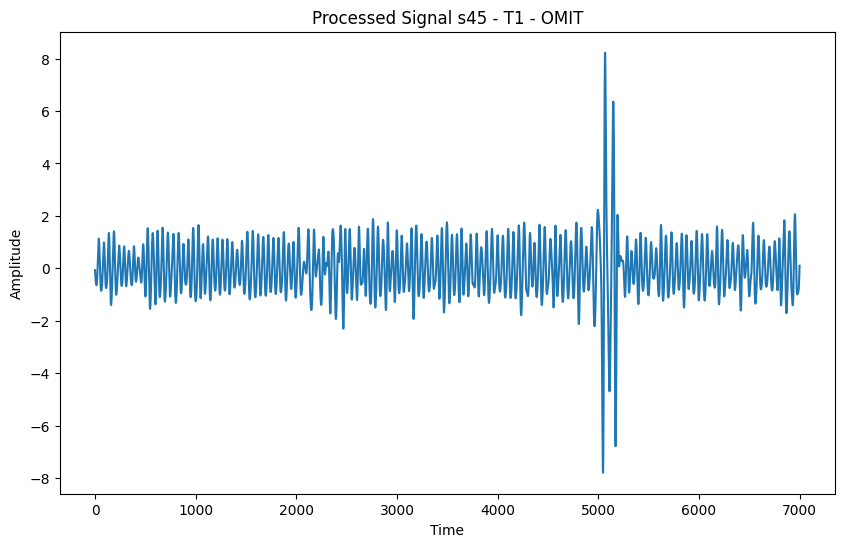

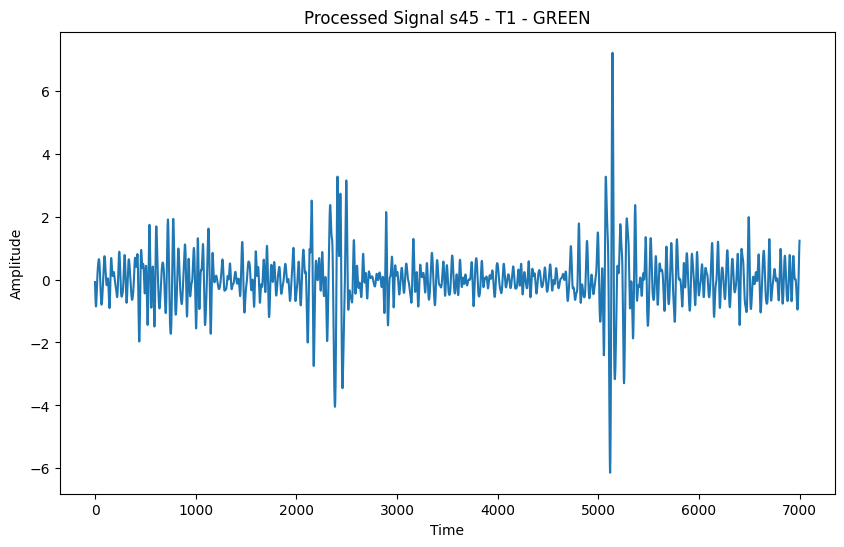

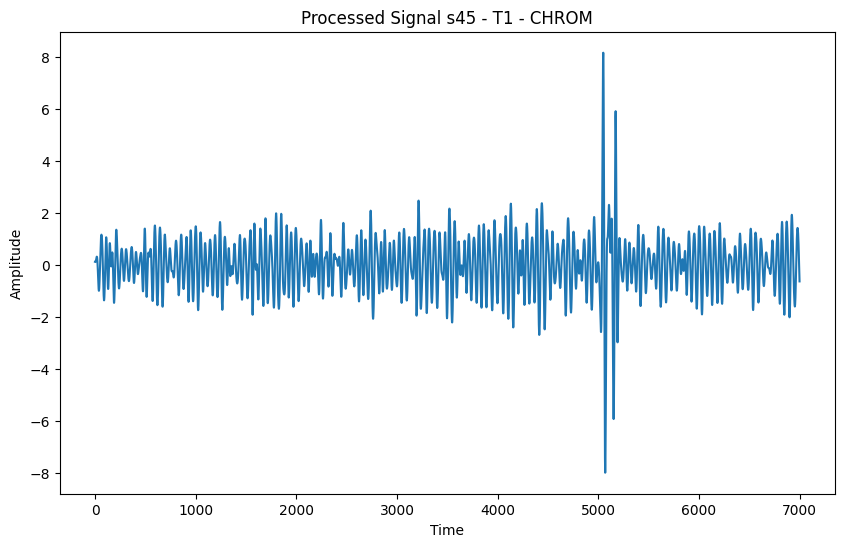

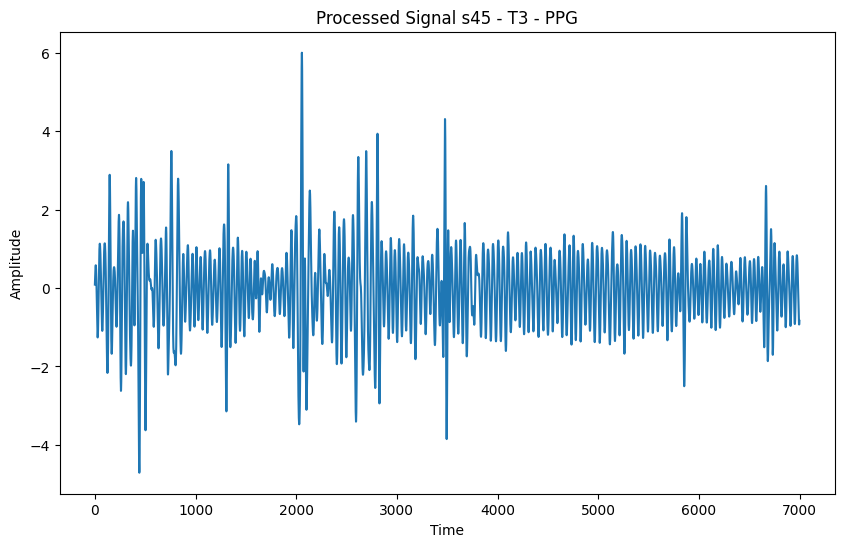

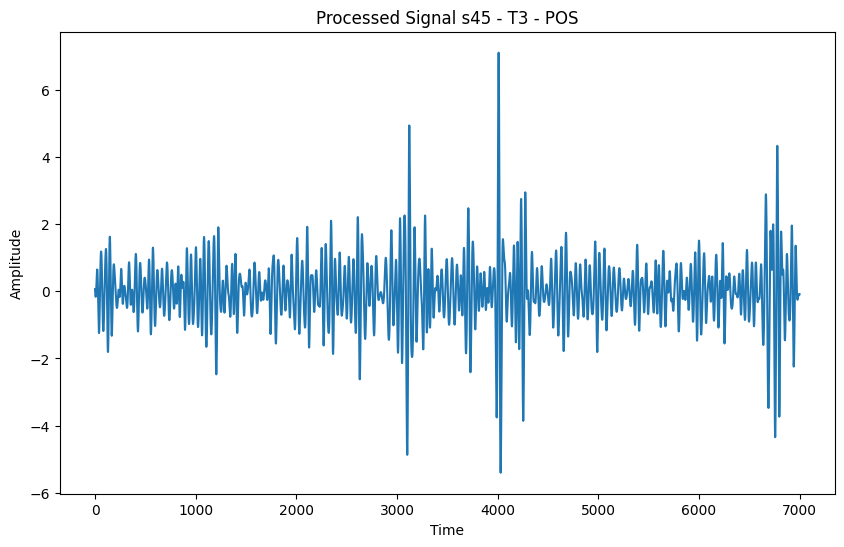

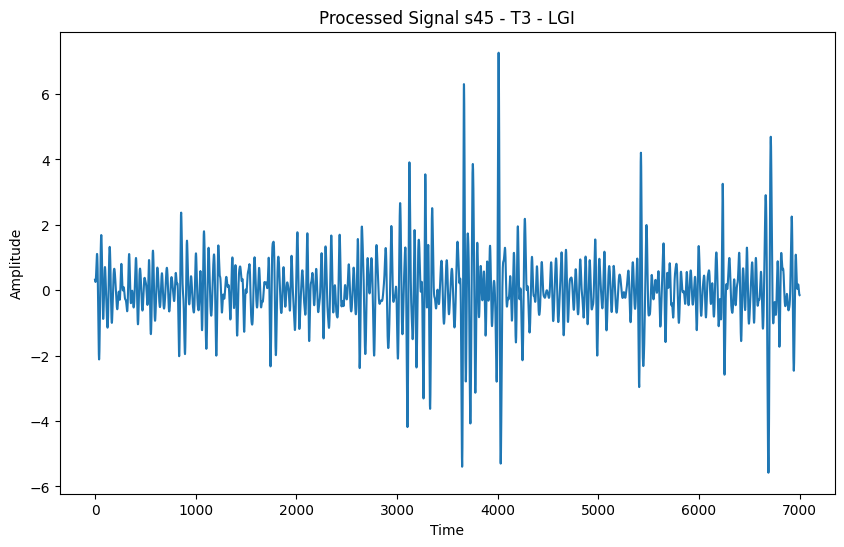

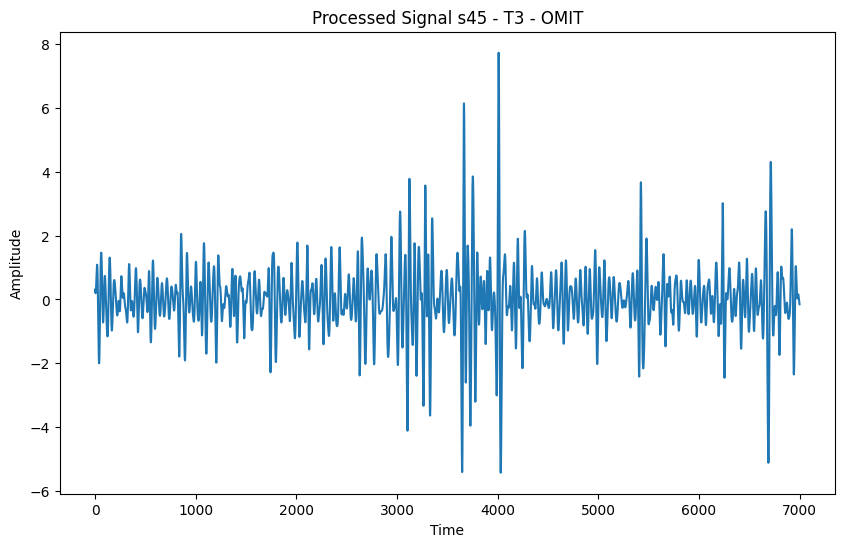

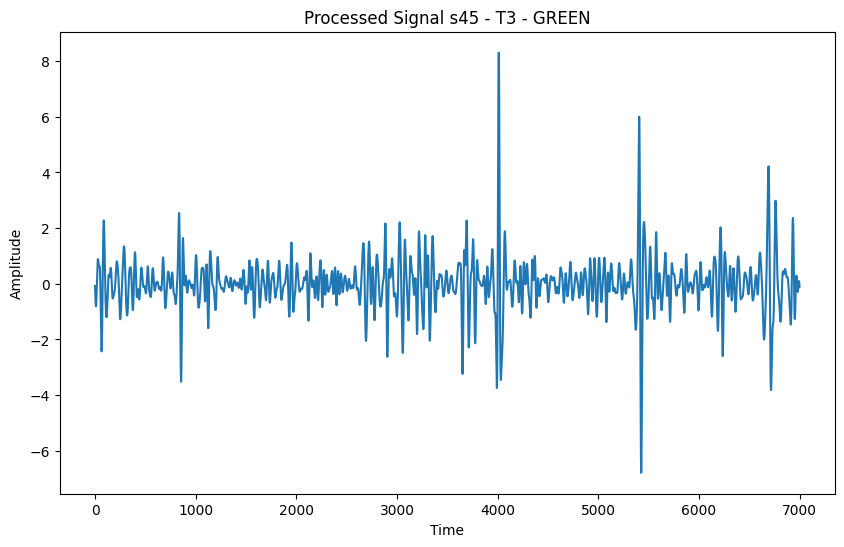

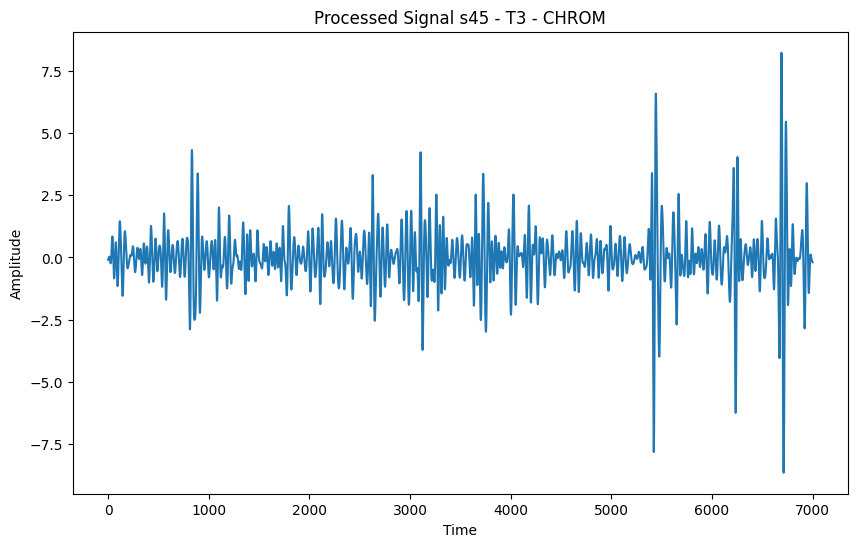

In [228]:
for signal in all_signals:
    # Plot the processed signal
    if signal.subject == "s45":
        plt.figure(figsize=(10, 6))
        plt.plot(signal.preprocessed[:7000])
        plt.title(f"Processed Signal {signal.subject} - {signal.task} - {signal.method}")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
    plt.show()

In [229]:
@dataclass
class MetricData:
    subject: str
    task: str
    method: str
    hr: float
    sdnn: float
    rmssd: float


In [252]:
## Define the method to compute the metrics
## This method will takes any signal (rPPG, PPG) 
# and it's sampling rate to get the HR and HRv
def compute_metrics(signal, fs):
    ## Compute the HR
    peaks , _ = scipy.signal.find_peaks(signal, prominence=0.15*np.std(signal))

    ## Getting the RR Interval / Jeda Waktu antar Puncak / Beat
    rr = np.diff(peaks) / fs  # Convert to unit seconds

    ## Clean the RR
    rr = np.asarray(rr, dtype=float)
    rr_intervals = rr[( rr >= 0.3 ) & (rr <= 2.0)] # Clean RR interval outside 0.3 - 2.0 seconds

    ## Calculating the HR
    hr = int(60 / np.mean(rr_intervals))

    ## Converting RR interval for milis for HRV analysis
    rr_intervals_ms = rr_intervals * 1000  # Convert to milliseconds

    ## Calculating the HRV (SDNN, RMSSD)
    ## Casting to Int for easier interpretation
    sdnn = int(np.std(rr_intervals_ms))
    rmssd = int(np.sqrt(np.mean(np.square(np.diff(rr_intervals_ms)))))

    print("Mean RR (s):", np.mean(rr_intervals))
    print("HR from RR:", 60 / np.mean(rr_intervals))
    print("Count of peaks:", len(peaks))
    print("Expected HR from peak count:", 60 * len(peaks) / (len(signal)/fs))
    print("HRV (SDNN, RMSSD):", sdnn, rmssd)
    print(" ================================ ")

    return hr, sdnn, rmssd

In [253]:
all_metrics = []

for sig in all_signals:
    ## Semua sinyal di resample ke 64 Hz
    hr, sdnn, rmssd = compute_metrics(sig.preprocessed, sig.fs) 
    all_metrics.append(MetricData(sig.subject, sig.task, sig.method, hr, sdnn, rmssd))


Mean RR (s): 0.6196474913494809
HR from RR: 96.82924701160458
Count of peaks: 290
Expected HR from peak count: 96.66666666666667
HRV (SDNN, RMSSD): 54 64
Mean RR (s): 0.6178879310344828
HR from RR: 97.10498779211719
Count of peaks: 291
Expected HR from peak count: 97.0
HRV (SDNN, RMSSD): 54 54
Mean RR (s): 0.6203503460207612
HR from RR: 96.71953982917901
Count of peaks: 290
Expected HR from peak count: 96.66666666666667
HRV (SDNN, RMSSD): 61 70
Mean RR (s): 0.6203503460207612
HR from RR: 96.71953982917901
Count of peaks: 290
Expected HR from peak count: 96.66666666666667
HRV (SDNN, RMSSD): 61 70
Mean RR (s): 0.6303367077464789
HR from RR: 95.18722178580781
Count of peaks: 286
Expected HR from peak count: 95.33333333333333
HRV (SDNN, RMSSD): 127 169
Mean RR (s): 0.6193771626297578
HR from RR: 96.87150837988825
Count of peaks: 291
Expected HR from peak count: 97.0
HRV (SDNN, RMSSD): 67 82
Mean RR (s): 0.6904447115384615
HR from RR: 86.90051353468535
Count of peaks: 261
Expected HR from p

In [254]:
df_metrics = pd.DataFrame([{
    "Subject": metrics.subject,
    "Task": metrics.task,
    "Method": metrics.method,
    "HR": metrics.hr,
    "SDNN": metrics.sdnn,
    "RMSSD": metrics.rmssd
} for metrics in all_metrics])


In [255]:
arrays = [
    [""] + ["Rest"]*6 + ["Task"]*6,
    ["Subject", "GT", "POS", "GREEN", "LGI", "OMIT", "CHROM",
     "GT", "POS", "GREEN", "LGI", "OMIT", "CHROM"]
]


columns = pd.MultiIndex.from_arrays(arrays)

In [256]:
rows = []

for subject in subjects:
    row = [subject]
    # Rest (T1) HR
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T1' and Method == @method")["HR"]
        row.append(val.values[0] if len(val) > 0 else None)
    # Task (T3) HR
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T3' and Method == @method")["HR"]
        row.append(val.values[0] if len(val) > 0 else None)

    rows.append(row)

df_hr = pd.DataFrame(rows, columns=columns)
df_hr

Rest                            Task                           
   Subject   GT  POS GREEN  LGI OMIT CHROM   GT  POS GREEN  LGI OMIT CHROM
0      s41   96   97    95   96   96    96   86  101    85  101  101   102
1      s42   71   73    86   72   72    75   87   97    85   93   93    93
2      s43   95   94    93   94   94    94   89   92    84   92   91    93
3      s44   63   72    75   67   67    74   70   73    81   66   66    78
4      s45   78   77    85   77   77    81   84   89    79   85   86    90
5      s46   74   74    74   74   74    75   89   90    96   92   92    89
6      s47   78   78    79   80   80    79   87   93    78   91   91    94
7      s48   76   72    75   74   74    73   83   88    85   87   88    88
8      s49  101  101    98  100  100   101   81   93    88   93   94    93
9      s50  103  102    98  102  102   102  104  104    94  103  104   104
10     s51   62   63    73   63   63    65   73   78    75   76   76    80
11     s52   78   89    89   89   89    89   82   88    90   88   88    88
12     s53   65   85    85   85   85    86   75   78    85   75   74    79
13     s54   89   93    90   92   92    93   92   92    90   92   92    92
14     s55   93   95    71   93   93    95   87   89    62   58   49    87
15     s56   83   87    86   84   84    88   83   88    90   89   89    91

In [257]:
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

eval_results = []

for cond in conditions:
    gt = df_hr[(cond, "GT")]  # ground truth for condition rest / task
    for method in methods:
        row=[method]
        pred = df_hr[(cond, method)]
        
        mae = mean_absolute_error(gt, pred)
        rmse = np.sqrt(np.mean((gt - pred) ** 2))
        pc, _ = pearsonr(gt, pred)
        
        eval_results.append({
            "Condition": cond,
            "Method": method,
            "MAE": mae,
            "RMSE": rmse,
            "PC": pc
        })

eval_df_hr = pd.DataFrame(eval_results)
print("HR (satuan: BPM)")
eval_df_hr

HR (satuan: BPM)


,Condition,Method,MAE,RMSE,PC
0,Rest,POS,3.8125,6.437197,0.895669
1,Rest,GREEN,7.1875,9.984363,0.671681
2,Rest,LGI,3.0625,5.921360,0.906060
3,Rest,OMIT,3.0625,5.921360,0.906060
4,Rest,CHROM,4.4375,6.959705,0.893892
5,Task,POS,5.0625,6.485561,0.864118
6,Task,GREEN,7.0625,9.031196,0.335249
7,Task,LGI,6.0625,9.337425,0.617763
8,Task,OMIT,6.7500,11.263880,0.539555
9,Task,CHROM,5.5625,7.031181,0.833141


In [259]:
rows = []

for subject in subjects:
    row = [subject]
    # Rest (T1) SDNN
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T1' and Method == @method")["SDNN"]
        row.append(val.values[0] if len(val) > 0 else None)
    # Task (T3) SDNN
    for method in ["PPG", "POS", "GREEN", "LGI", "OMIT", "CHROM"]:
        val = df_metrics.query("Subject == @subject and Task == 'T3' and Method == @method")["SDNN"]
        row.append(val.values[0] if len(val) > 0 else None)

    rows.append(row)

df_sdnn = pd.DataFrame(rows, columns=columns)
print("SDNN (Satuan: ms)")
df_sdnn


SDNN (Satuan: ms)


Rest                            Task                           
   Subject   GT  POS GREEN  LGI OMIT CHROM   GT  POS GREEN  LGI OMIT CHROM
0      s41   54   54   127   61   61    67  217   76   235   95  103    99
1      s42  112  118   214  124  124   169  158  141   239  183  182   172
2      s43   45   51   118   82   82    46  130  140   238  155  156   133
3      s44  152  221   248  206  212   236  200  201   245  216  215   230
4      s45   97   86   222   91   91   137  112  130   250  174  167   162
5      s46   59   59    66   59   59    86   93  108   185  140  146   134
6      s47   81   86   186  120  121   116  232  102   243  133  127   114
7      s48  275   91   191  138  138   124  250  158   237  207  202   166
8      s49   42   42   146   79   79    44  245  129   218  171  163   135
9      s50   28   39   154   49   49    61   70   57   191   75   76    82
10     s51   80  118   229   97   97   168  136  152   264  150  151   180
11     s52  192   99   187  106  106   105  197  130   226  146  145   136
12     s53  123  141   175  143  143   152  233  153   220  142  141   166
13     s54  125   52   155   94   99    63   92  100   218  170  165   128
14     s55  140  107   311  131  129   115  120  129   314  369  245   161
15     s56  215  115   241  133  143   142  194  146   222  169  169   162

In [260]:
methods = ["POS", "GREEN", "LGI", "OMIT", "CHROM"]
conditions = ["Rest", "Task"]

eval_results = []

for cond in conditions:
    gt = df_sdnn[(cond, "GT")]  # ground truth for condition rest / task
    for method in methods:
        row=[method]
        pred = df_sdnn[(cond, method)]
        
        mae = mean_absolute_error(gt, pred)
        rmse = np.sqrt(np.mean((gt - pred) ** 2))
        pc, _ = pearsonr(gt, pred)
        
        eval_results.append({
            "Condition": cond,
            "Method": method,
            "MAE": mae,
            "RMSE": rmse,
            "PC": pc
        })

eval_df_sdnn = pd.DataFrame(eval_results)
eval_df_sdnn

,Condition,Method,MAE,RMSE,PC
0,Rest,POS,40.4375,64.124391,0.468019
1,Rest,GREEN,83.0000,95.679151,0.489492
2,Rest,LGI,37.1875,51.517594,0.645963
3,Rest,OMIT,36.8125,50.893885,0.653154
4,Rest,CHROM,50.4375,63.183760,0.448883
5,Task,POS,48.8125,67.732470,0.381426
6,Task,GREEN,73.2500,92.002717,0.065351
7,Task,LGI,64.1250,86.379251,-0.019720
8,Task,OMIT,56.8750,67.716320,0.101069
9,Task,CHROM,53.8125,64.508236,0.207864


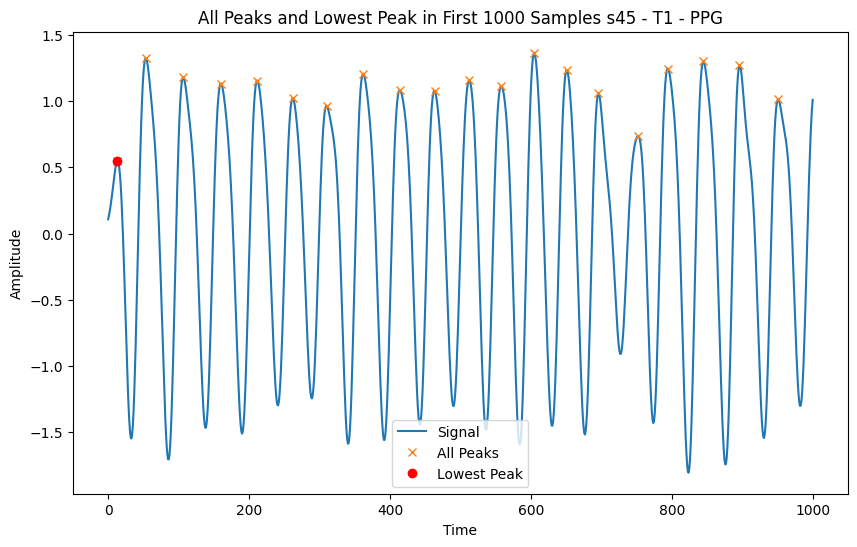

IBI for s45 - T1 - PPG - Len 19: [0.625    0.828125 0.84375  0.796875 0.796875 0.75     0.8125   0.8125
 0.765625 0.765625 0.703125 0.734375 0.71875  0.703125 0.875    0.671875
 0.78125  0.796875 0.859375]


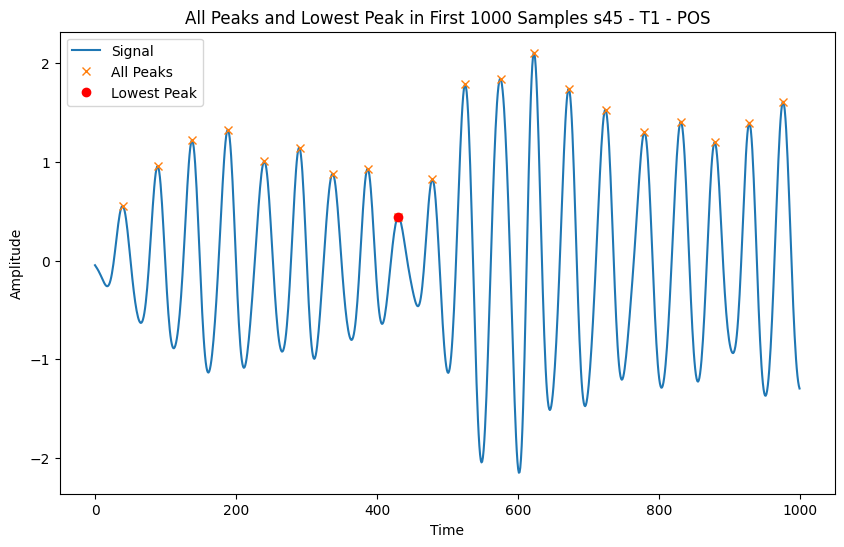

IBI for s45 - T1 - POS - Len 19: [0.78125  0.765625 0.78125  0.8125   0.78125  0.734375 0.78125  0.671875
 0.75     0.734375 0.78125  0.734375 0.78125  0.8125   0.859375 0.8125
 0.75     0.765625 0.75    ]


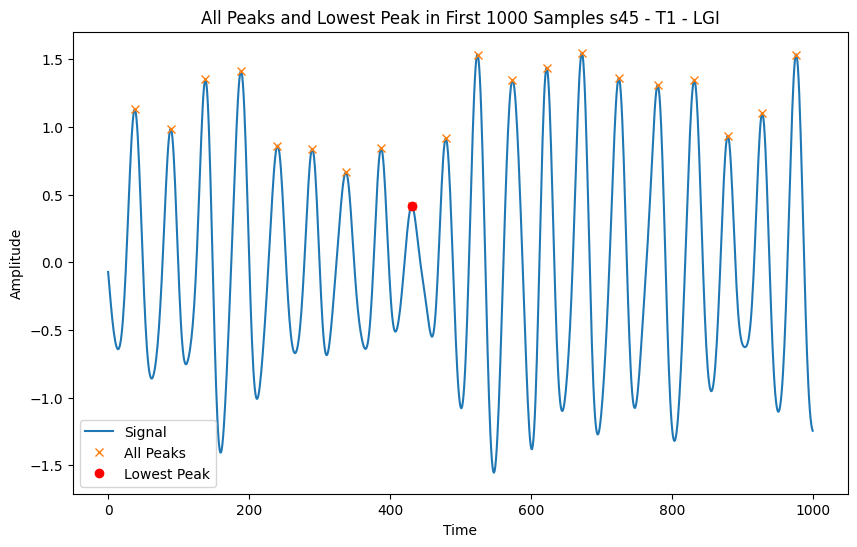

IBI for s45 - T1 - LGI - Len 19: [0.796875 0.765625 0.78125  0.8125   0.765625 0.75     0.78125  0.6875
 0.75     0.703125 0.765625 0.765625 0.78125  0.8125   0.859375 0.8125
 0.75     0.75     0.765625]


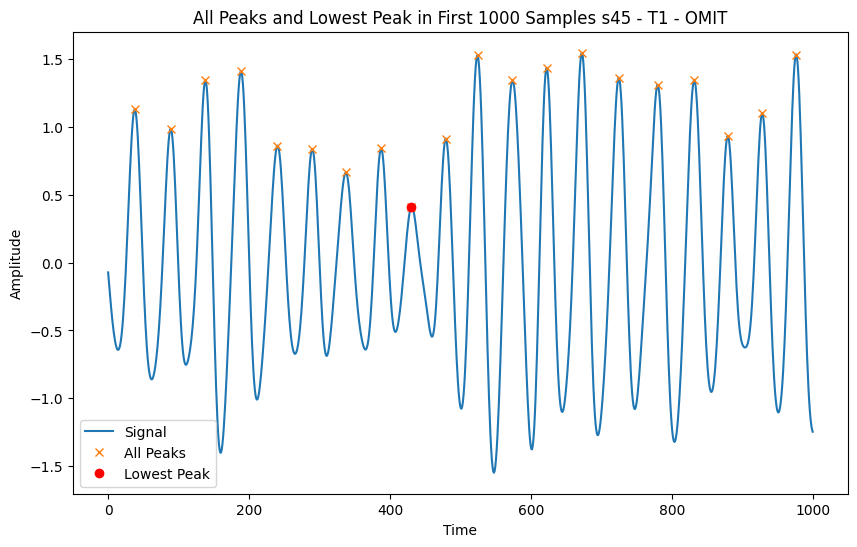

IBI for s45 - T1 - OMIT - Len 19: [0.796875 0.765625 0.78125  0.8125   0.765625 0.75     0.78125  0.671875
 0.765625 0.703125 0.765625 0.765625 0.78125  0.8125   0.859375 0.8125
 0.75     0.75     0.765625]


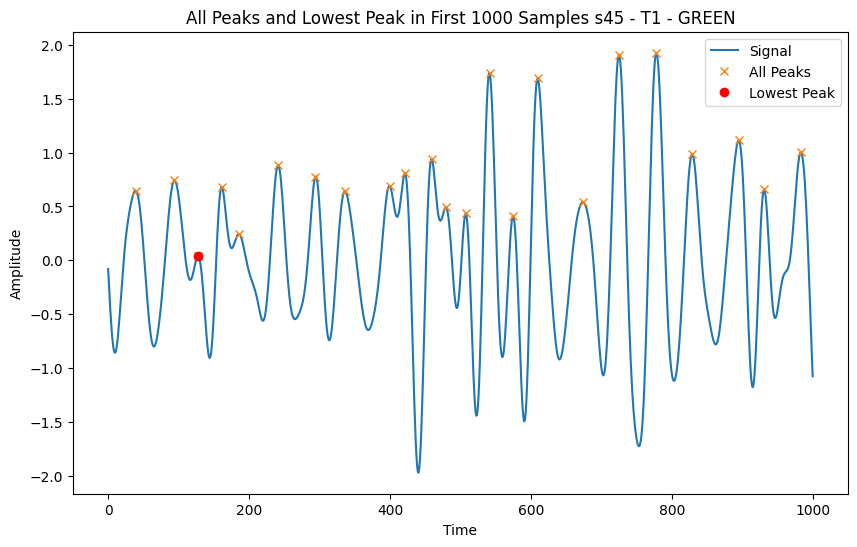

IBI for s45 - T1 - GREEN - Len 22: [0.859375 0.515625 0.53125  0.375    0.875    0.828125 0.65625  0.984375
 0.34375  0.59375  0.3125   0.4375   0.53125  0.515625 0.546875 1.
 0.796875 0.828125 0.796875 1.03125  0.5625   0.8125  ]


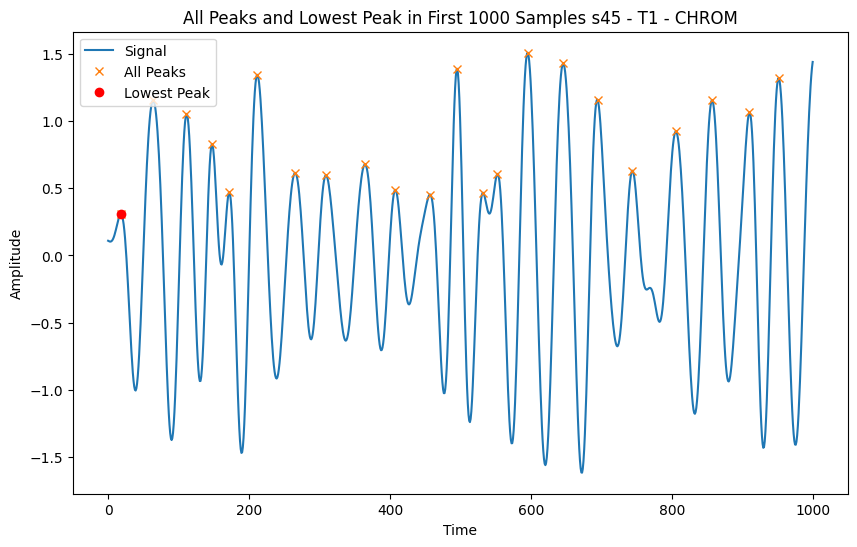

IBI for s45 - T1 - CHROM - Len 21: [0.71875  0.734375 0.5625   0.390625 0.609375 0.84375  0.6875   0.859375
 0.671875 0.765625 0.609375 0.5625   0.328125 0.671875 0.78125  0.765625
 0.765625 0.96875  0.796875 0.828125 0.65625 ]


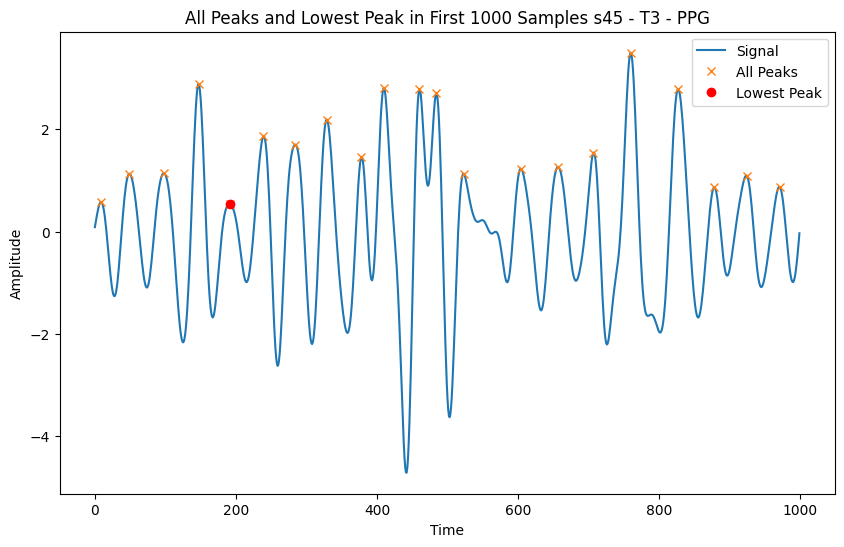

IBI for s45 - T3 - PPG - Len 20: [0.625    0.765625 0.765625 0.6875   0.75     0.703125 0.703125 0.765625
 0.5      0.78125  0.375    0.609375 1.265625 0.828125 0.78125  0.828125
 1.046875 0.796875 0.71875  0.734375]


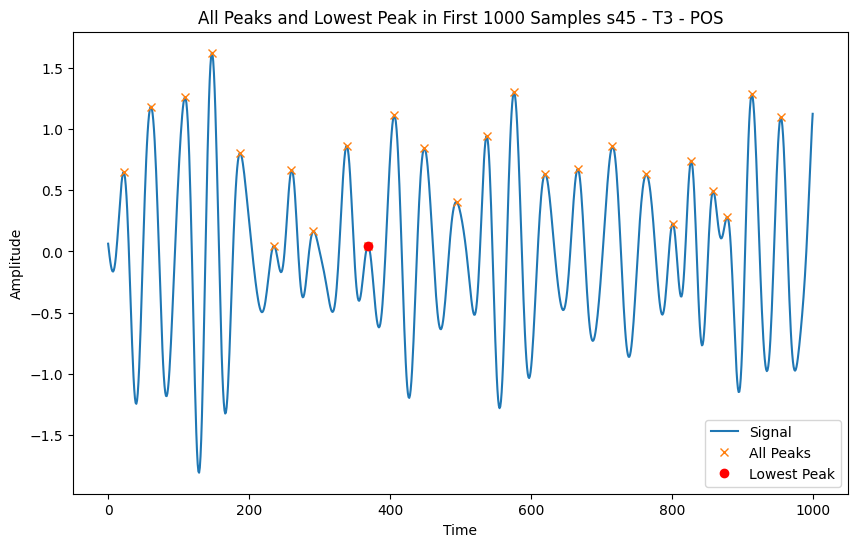

IBI for s45 - T3 - POS - Len 24: [0.609375 0.75     0.59375  0.625    0.75     0.390625 0.484375 0.734375
 0.46875  0.59375  0.65625  0.71875  0.671875 0.609375 0.6875   0.71875
 0.765625 0.75     0.59375  0.40625  0.484375 0.3125   0.546875 0.640625]


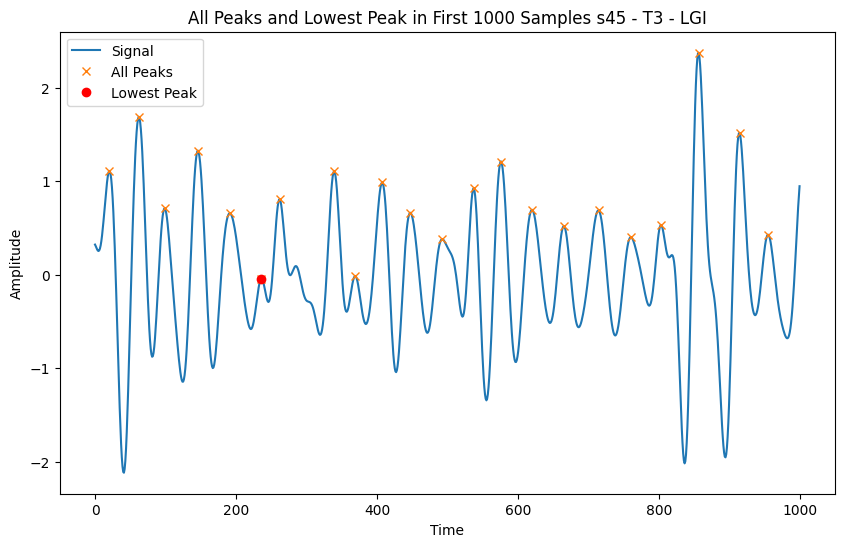

IBI for s45 - T3 - LGI - Len 21: [0.65625  0.578125 0.734375 0.703125 0.703125 0.40625  1.203125 0.46875
 0.59375  0.625    0.703125 0.703125 0.609375 0.6875   0.703125 0.765625
 0.71875  0.671875 0.828125 0.90625  0.625   ]


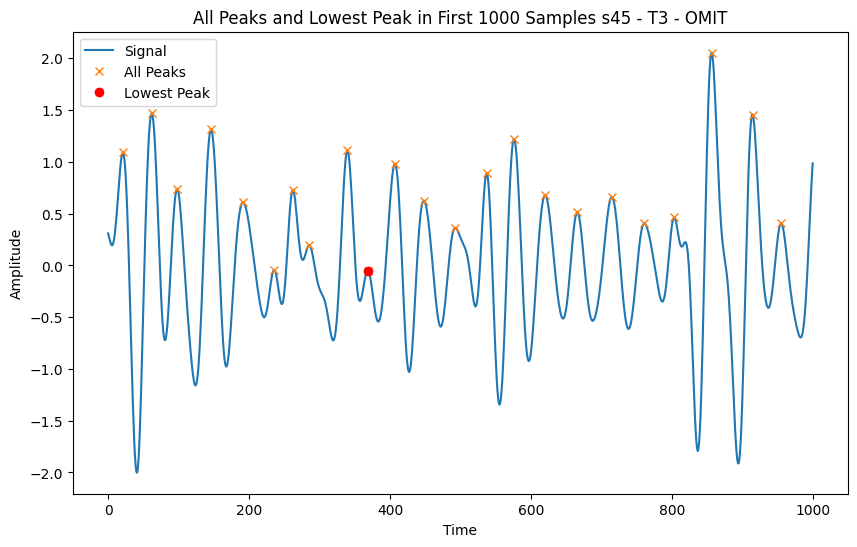

IBI for s45 - T3 - OMIT - Len 22: [0.640625 0.5625   0.75     0.703125 0.6875   0.421875 0.359375 0.84375
 0.453125 0.609375 0.640625 0.6875   0.703125 0.609375 0.6875   0.703125
 0.765625 0.71875  0.671875 0.828125 0.90625  0.625   ]


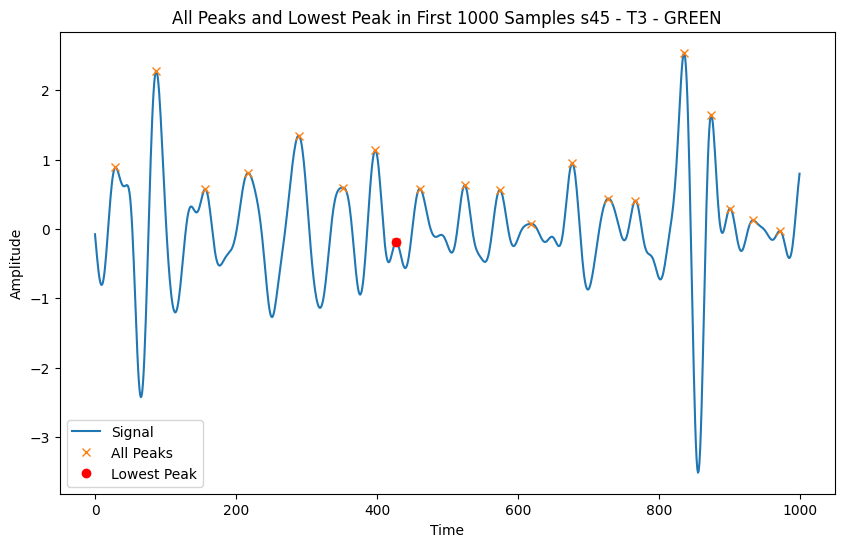

IBI for s45 - T3 - GREEN - Len 19: [0.90625  1.078125 0.953125 1.125    0.96875  0.71875  0.46875  0.53125
 0.984375 0.78125  0.6875   0.921875 0.796875 0.59375  1.078125 0.609375
 0.40625  0.515625 0.59375 ]


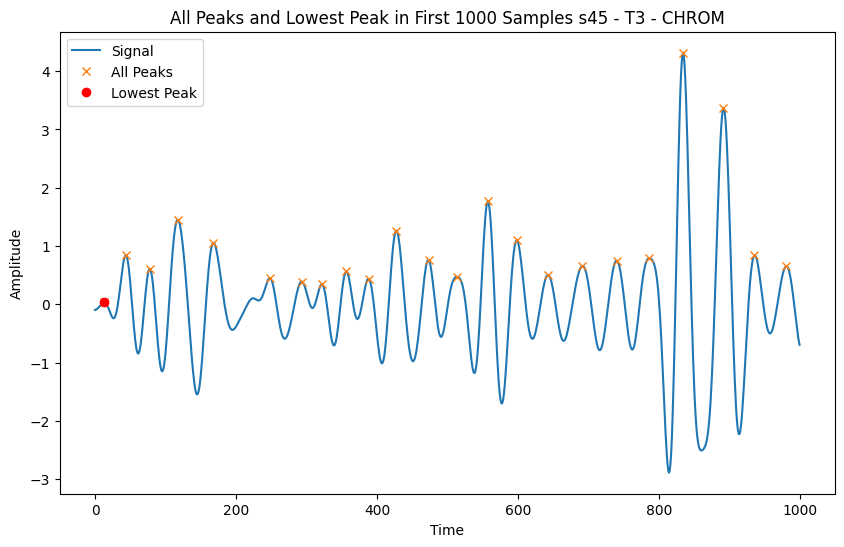

IBI for s45 - T3 - CHROM - Len 22: [0.484375 0.53125  0.609375 0.796875 1.25     0.703125 0.453125 0.53125
 0.5      0.609375 0.71875  0.625    0.6875   0.640625 0.6875   0.765625
 0.765625 0.71875  0.75     0.890625 0.6875   0.703125]


In [261]:
for signal in all_signals:
    if signal.subject == "s45":
        # Find all peaks in the first 1000 samples
        peaks, _ = scipy.signal.find_peaks(signal.preprocessed[:1000], prominence=0.1)
        # Divide the peaks to get the IBI
        ibi = np.diff(peaks) / signal.fs 
        plt.figure(figsize=(10, 6))
        plt.plot(signal.preprocessed[:1000], label="Signal")
        # Plot all peaks
        plt.plot(peaks, signal.preprocessed[peaks], "x", label="All Peaks")
        if len(peaks) > 0:
            # Find and plot the lowest peak
            lowest_peak_idx = np.argmin(signal.preprocessed[peaks])
            lowest_peak = peaks[lowest_peak_idx]
            plt.plot([lowest_peak], [signal.preprocessed[lowest_peak]], "ro", label="Lowest Peak")
        plt.title(f"All Peaks and Lowest Peak in First 1000 Samples {signal.subject} - {signal.task} - {signal.method}")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.legend()
        plt.show()
        print(f"IBI for {signal.subject} - {signal.task} - {signal.method} - Len {len(ibi)}: {ibi}")